This script only runs from within Meteowiss, because of the data store. It compiles raw data files stored on MeteoSwiss disk into parquet files. 
Incoming raw data files are first organized into folders, and a stastic is computed and displayed showing the number of recently incoming files.
Then, yearly files are generated for Meteo bulletins, Thermo zip files, NOAA CPD2 tarballs. Monthly files are generated for AE33 zip files, G2401 tarballs.

joerg.klausen@meteoswiss.ch

[TODO] Improve handling of erroneous files from g2401.compile_g2401_to_parquet

In [1]:
import os
import polars as pl
import housekeeping.organize_files as hk
import monitoring.file_coverage as fc
from processing.meteo import Meteo
from processing.thermo import Thermo
from processing.cpd2 import CPD2
from processing.ae33 import AE33
from processing.g2401 import G2401
from processing.dobson import DData
from toolbox.utils import setup_logging, load_config

# relative path of level1 data .parquet files on repo
level1 = os.path.join("data", "level1")
os.makedirs(level1, exist_ok=True)

In [ ]:
##############################
# Process MKN incoming files #
##############################
# read configuration
mkn = load_config(config_file="mch-mkn.yml")

# setup logging
logger = setup_logging(os.path.join(os.getcwd(), mkn['logging']))

# organize MKN files on MeteoSwiss fileshare
n = hk.organize_files(mkn, branch=mkn['branches']["incoming"], verbosity=1)

# show and plot file statistics
days = 7
stats = fc.get_file_coverage(cfg=mkn, days=days)
display(df:=fc.print_coverage(stats=stats, days=days))
fc.plot_coverage(stats=stats, days=days)

In [ ]:
for k, v in mkn['branches'].items():
    if not os.path.exists(os.path.join(mkn['root'], v)):
        raise ValueError(f"path '{v}' not found.")

# path of source files
incoming = os.path.join(mkn['root'], mkn['branches']['incoming'])

# path of archive for successfully processed raw data files.
archive = os.path.join(mkn['root'], mkn['branches']['archive'])

# path for raw data files with issues
issues = os.path.join(mkn['root'], mkn['branches']['issues'])

# path for log files
logs = os.path.join(mkn['root'], mkn['branches']['logs'])

# instantiate instruments (rather, data types)
met = Meteo(log=os.path.join(logs, "meteo.log"))
thermo = Thermo(log=os.path.join(logs, "thermo.log"))
cpd2 = CPD2(log=os.path.join(logs, "cpd2.log"))
ae33 = AE33(log=os.path.join(logs, "ae33.log"))
g2401 = G2401(log=os.path.join(logs, "g2401.log"))

# process all raw data types
years = [f"{year}" for year in range(2021, 2025)]
months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]

for year in years:
    met.compile_vrxa00_to_parquet(
        source=os.path.join(incoming, "meteo", year), 
        target=os.path.join(level1, year), 
        archive=os.path.join(archive, "meteo", year), 
        issues=os.path.join(issues, "meteo"),
        )
    thermo.compile_thermo_to_parquet(
        source=os.path.join(incoming, "tei49c", year),
        target=os.path.join(level1, year),
        archive=os.path.join(archive, "tei49c", year),
        issues=os.path.join(issues, "tei49c"),
        )        
    thermo.compile_thermo_to_parquet(
        source=os.path.join(incoming, "tei49i", year),
        target=os.path.join(level1, year),
        archive=os.path.join(archive, "tei49i", year),
        issues=os.path.join(issues, "tei49i"),
        )
    cpd2.tarballs_to_parquet(
        source=os.path.join(incoming, "aerosol", year), 
        target=os.path.join(level1, year), 
        archive=os.path.join(archive, "aerosol", year), 
        issues=os.path.join(issues, "aerosol"),
        )
    for month in months:
        if os.path.exists(incoming):
            ae33.zipfiles_to_parquet(
                source=os.path.join(incoming, "ae33", "data", year, month), 
                target=os.path.join(level1, year, month), 
                archive=os.path.join(archive, "ae33", "data", year, month), 
                issues=os.path.join(issues, "ae33"), 
                plot=True,
                )
            g2401.compile_g2401_to_parquet(
                source=os.path.join(incoming, "g2401", year, month), 
                target=os.path.join(level1, year, month), 
                archive=os.path.join(archive, "g2401", year, month), 
                issues=os.path.join(issues, "g2401", year),
                )

In [ ]:
# display empty directories under source
# os.system(f"find {source} -empty -type d)

# display empty directories under source (NB: no questions asked!)
# os.system(f"find {source} -empty -type d -delete")

Finished organizing files under '/product_data/data/pay/Kenya'. 0 files moved.


2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Initialize DData
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Initialize DData
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Processing /product_data/data/pay/Kenya/uploads ...
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Processing /product_data/data/pay/Kenya/uploads ...
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Processing ReadMe.txt ...
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Processing ReadMe.txt ...
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Reading file /product_data/data/pay/Kenya/uploads/ReadMe.txt
2024-08-15T12:17:11, INFO, mch-nrb.processing.dobson, Reading file /product_data/data/pay/Kenya/uploads/ReadMe.txt
2024-08-15T12:17:11, ERROR, mch-nrb.processing.dobson, Error reading ReadMe.txt: Header section not recognized, giving up.
2024-08-15T12:17:11, ERROR, mch-nrb.processing.dobson, Error reading ReadMe.txt: Header section not recognized, giving up.
2024-08-15

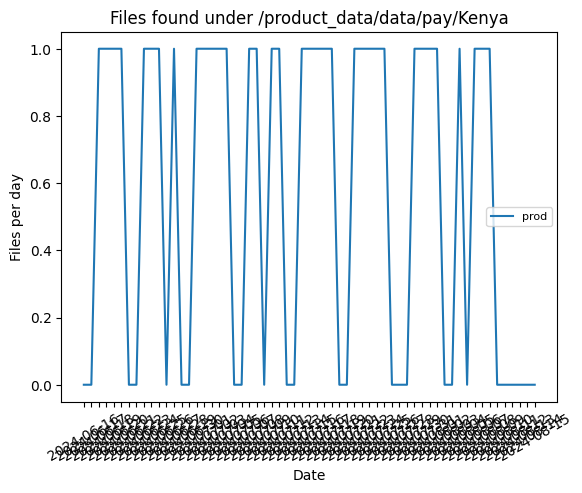

In [3]:
##############################
# Process NRB incoming files #
##############################
# read configuration
nrb = load_config(config_file="mch-nrb.yml")

# setup logging
logger = setup_logging(os.path.join(os.getcwd(), nrb["nrb-dobson"]['logging']))


n = hk.organize_files(nrb["nrb-dobson"], branch="uploads")
print(f"Finished organizing files under '{nrb['nrb-dobson']['root']}'. {n} files moved.")

days = 60
stats = fc.get_file_coverage(cfg=nrb['nrb-dobson'], days=days)
fc.plot_coverage(stats=stats, days=days)
fc.print_coverage(stats=stats, days=days)

ddata = DData(config=nrb['nrb-dobson'])
headers, df_data = ddata.process_directory(os.path.join(nrb['nrb-dobson']["root"], nrb['nrb-dobson']['branches']['uploads']))
df_data.write_parquet(os.path.join(level1, 'd018_nrb_data.parquet'))

df_headers = pl.DataFrame(headers, orient='row')
df_headers.write_parquet(os.path.join(level1, 'd018_nrb_headers.parquet'))


In [16]:
file = 'data/level1/d018_nrb_data.parquet'
df = pl.read_parquet(file)
df = df.with_columns(pl.col('dtm').str.to_datetime(),
                     pl.col('sza').cast(pl.Float64),
                     pl.col('mu').cast(pl.Float64),
                     pl.col('XAD').cast(pl.Float64),
                     pl.col('X1').cast(pl.Float64),
                     pl.col('X2').cast(pl.Float64),
                     pl.col('X3').cast(pl.Float64),
                     pl.col('X4').cast(pl.Float64),
                     pl.col('X5').cast(pl.Float64),)
display(df.describe())

display(df.plot(x='dtm', y='sza'))
display(df.plot(x='dtm', y='mu'))
display(df.plot(x='dtm', y='XAD'))




statistic,source,type,sequence,comments,dtm,sza,mu,XAD,XCD,X1,X2,X3,X4,X5,X6,X7
str,str,str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,str,str
"""count""","""7066""","""7066""","""7066""","""7066""","""7066""",7066.0,7066.0,7066.0,"""7066""",7066.0,7066.0,7066.0,7066.0,7066.0,"""7066""","""7066"""
"""null_count""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,null,null,"""2023-07-09 21:…",39.277286,1.339184,272.749575,null,150.900977,165.289541,150.707784,165.391537,150.757048,null,null
"""std""",null,null,null,null,null,11.249621,0.202593,1547.61725,null,133.037858,149.269567,132.741414,149.399251,132.939529,null,null
"""min""","""D0022024.018""","""DS""","""ADADA""","""/8, 20, ZC""","""2020-08-24 12:…",11.2,1.019,-72.9,"""""",-212.1,-1022.9,-177.0,-168.9,-211.1,"""""",""""""
"""25%""",null,null,null,null,"""2023-01-23 11:…",29.9,1.152,244.8,null,0.0,0.0,0.0,0.0,0.0,null,null
"""50%""",null,null,null,null,"""2023-07-13 11:…",41.3,1.327,254.8,null,246.3,256.9,246.2,256.7,246.1,null,null
"""75%""",null,null,null,null,"""2024-02-02 11:…",48.4,1.499,262.4,null,267.2,295.1,267.4,295.1,267.4,null,null
"""max""","""DDataD2552022.…","""ZC""","""ADADA""","""ZC""","""2024-08-09 12:…",158.4,2.476,130318.1,"""""",1071.5,1329.3,1189.7,1426.6,950.2,"""""",""""""


:Curve   [dtm]   (sza)

:Curve   [dtm]   (mu)

:Curve   [dtm]   (XAD)

In [ ]:
# Brewer B071 file statistics
days = 7
stats = fc.get_file_coverage(cfg=nrb["nrb-brewer"], days=days)
fc.plot_coverage(stats=stats, days=days)
fc.print_coverage(stats=stats, days=days)